In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/Sleep_Health_and_Lifestyle_Dataset.csv")  # path from notebooks folder

# Show first few rows
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [3]:
#keeping only required variables
df_h3 = df[['Daily Steps', 'Sleep Duration']].copy()
df_h3.head()

,Daily Steps,Sleep Duration
0,4200,6.1
1,10000,6.2
2,10000,6.2
3,3000,5.9
4,3000,5.9


In [4]:
#checking for the empty values,negative values and basic stats
df_h3.describe()

,Daily Steps,Sleep Duration
count,374.000000,374.000000
mean,6816.844920,7.132086
std,1617.915679,0.795657
min,3000.000000,5.800000
25%,5600.000000,6.400000
50%,7000.000000,7.200000
75%,8000.000000,7.800000
max,10000.000000,8.500000


In [5]:
from scipy.stats import shapiro

stat1, p1 = shapiro(df_h3['Daily Steps'])
stat2, p2 = shapiro(df_h3['Sleep Duration'])

print("Daily Steps p-value:", p1)
print("Sleep Duration p-value:", p2)


Daily Steps p-value: 1.6531796290397034e-11
Sleep Duration p-value: 1.2678283000990912e-11


In [6]:
#Daily Steps: 1.65 × 10⁻¹¹ (very small → NOT normal)
#Sleep Duration: 1.26 × 10⁻¹¹ (very small → NOT normal)
#go for spearman test for correlation since they are not normal
from scipy.stats import spearmanr

corr, p_value = spearmanr(df_h3['Daily Steps'], df_h3['Sleep Duration'])

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: 0.010086583810612584
p-value: 0.8458491978996143


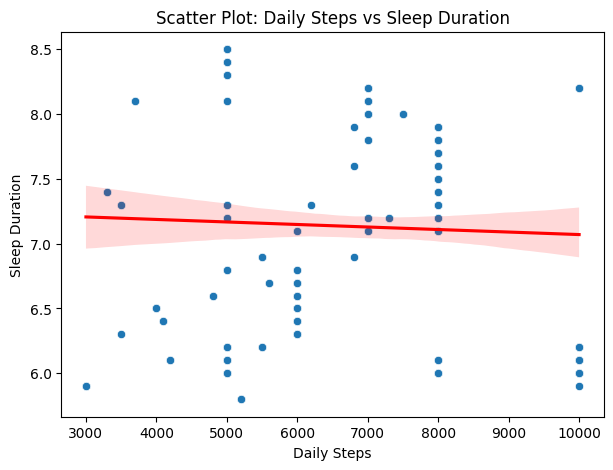

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Daily Steps', y='Sleep Duration')

# Optional: add regression line (even though correlation is near zero)
sns.regplot(data=df, x='Daily Steps', y='Sleep Duration', scatter=False, color='red')

plt.title("Scatter Plot: Daily Steps vs Sleep Duration")
plt.show()

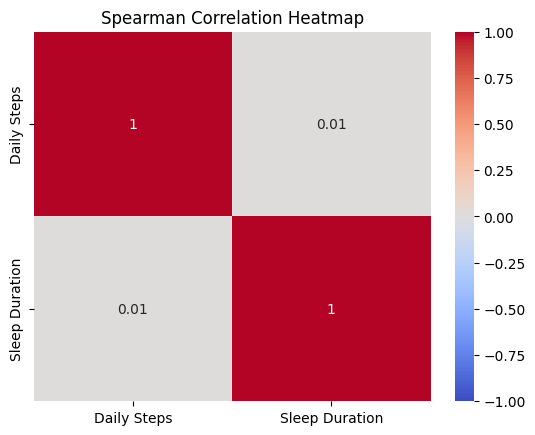

In [8]:
corr = df_h3[['Daily Steps', 'Sleep Duration']].corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap")
plt.show()

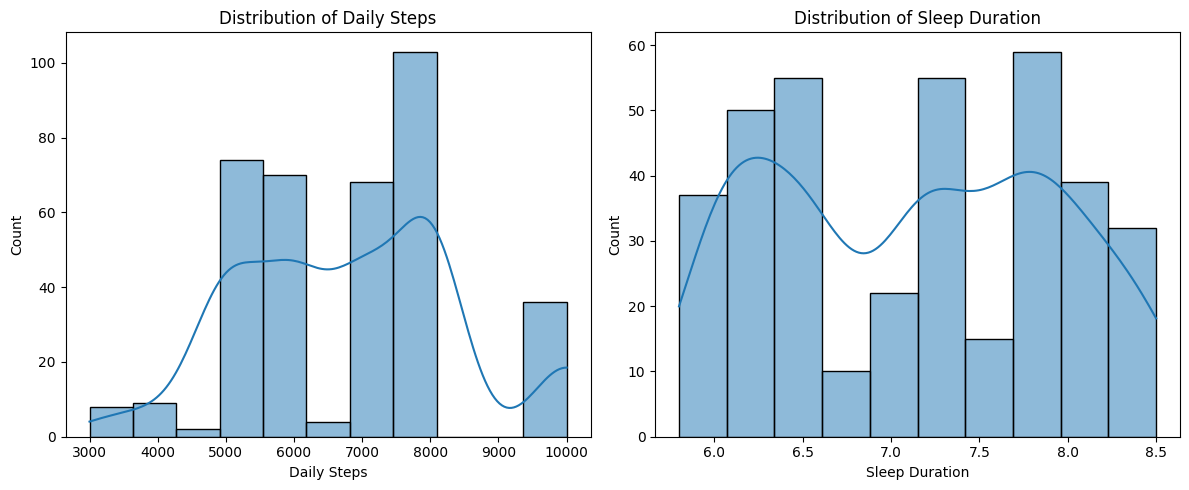

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Daily Steps'], kde=True)
plt.title("Distribution of Daily Steps")

plt.subplot(1,2,2)
sns.histplot(df['Sleep Duration'], kde=True)
plt.title("Distribution of Sleep Duration")

plt.tight_layout()
plt.show()